In [29]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [30]:
class Batsman(TypedDict):

    runs: int
    balls: int
    fours: int
    sixes: int
    strike_rate: float
    bpb: int
    bp: float


In [31]:
def calculate_sr(state: Batsman):

   sr = (state['runs']/state['balls'])*100

   state['sr'] = sr

   return state

In [32]:
def calculate_bpb(state: Batsman):

    bpb = (state['balls']/state['fours'] + state['sixes'])

    state['bpb'] = bpb

    return state

In [33]:
def calculate_bp(state: Batsman):

    bp = (((state['fours'] * 4 + state['sixes'] * 6))/state['runs'])*100

    state['bp'] = bp

    return state


In [34]:
graph = StateGraph(Batsman)

graph.add_node('calculate_sr', calculate_sr)
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('calculate_bp',calculate_bp)

In [35]:
graph.add_edge(START,'calculate_sr')
graph.add_edge(START,'calculate_bpb')
graph.add_edge(START,'calculate_bp')


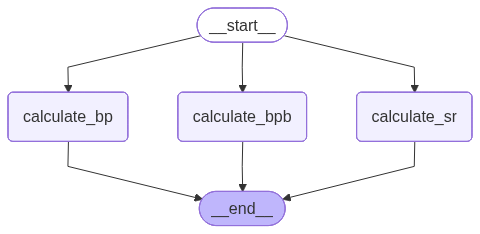

In [37]:
graph.compile()